<div style="width:100%; max-width:900px; margin:0 auto 1.5em auto;">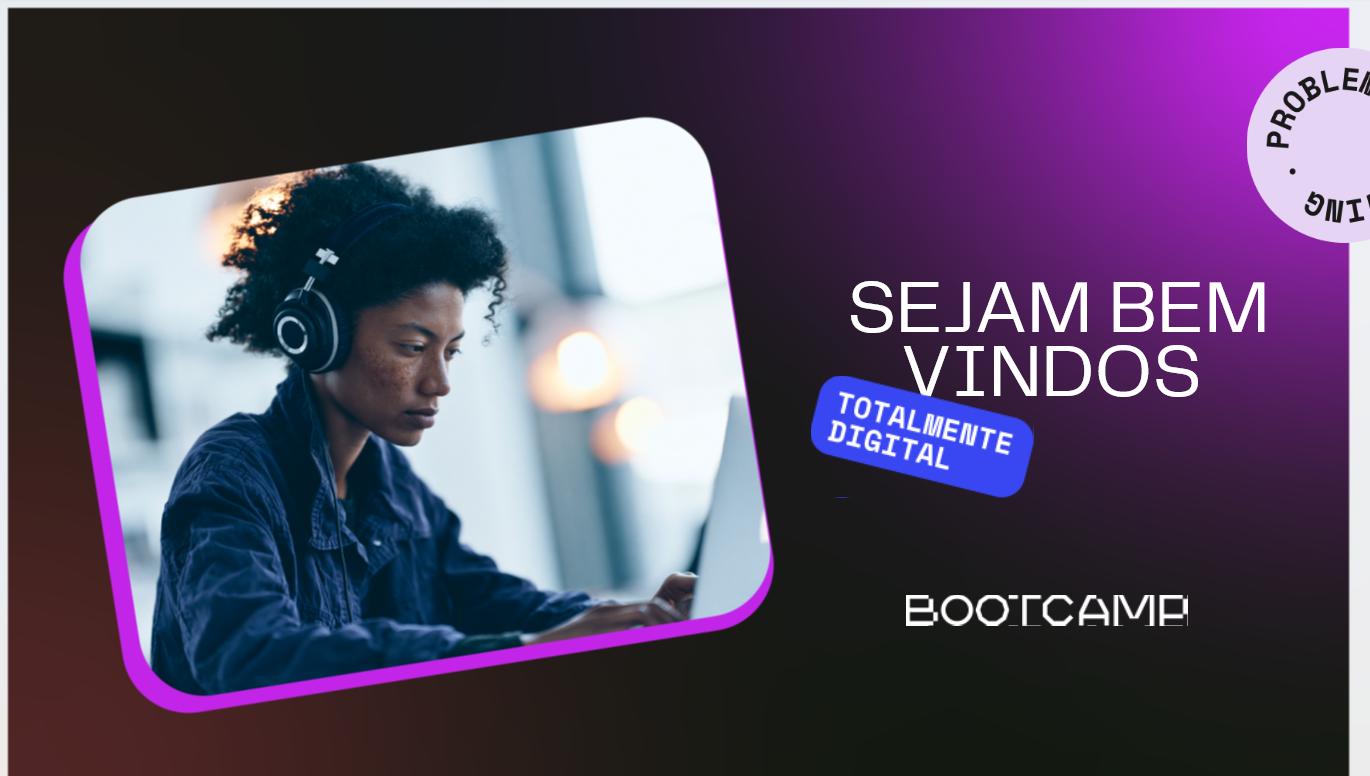</div>

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">BootCamp Nova Geração — Arquiteturas de Agentes com LangGraph + LiteLLM</h1>

Este notebook transforma as cinco arquiteturas do bootcamp em implementações com Python, em um cenário fictício de **operações logísticas**. A proposta é enxergar, na prática, como a arquitetura altera o fluxo de decisão, as tools disponíveis, o estado e os mecanismos de controle do agente.

As arquiteturas implementadas são:

1. **ReAct** — decidir → usar tool → observar → decidir novamente;
2. **Planejamento** — planner → executor → replanner → síntese;
3. **Memória** — continuidade por estado persistido;
4. **Multiagente** — orquestrador + especialistas + consolidação;
5. **Reflexão** — gerar → criticar por rubrica → revisar.

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">👩‍💻 Não conhece Python? Este notebook também foi feito para você</h2>

**Você não precisa saber programar para acompanhar o exercício.** O código foi propositalmente escrito como um roteiro comentado. Antes das instruções importantes existe uma linha iniciada por `#` explicando, em linguagem simples, **o que aquela próxima linha executa e qual papel ela cumpre na arquitetura**.

Ao avançar pelas células, use esta sequência de leitura:

1. **Leia primeiro os comentários iniciados por `#`.** Eles funcionam como a narração do passo a passo.
2. **Observe a linha de código logo abaixo do comentário.** Não é necessário memorizar a sintaxe; procure apenas associar a explicação à execução.
3. **Nos trechos de LangGraph, procure os conceitos arquiteturais:** estado, nó, aresta, tool, roteamento, memória e critérios de parada.
4. **Execute as células na ordem**, de cima para baixo. As células posteriores reutilizam variáveis e funções criadas anteriormente.
5. **Nas células de interação, escreva seu próprio prompt** quando aparecer `input(...)` e observe como cada arquitetura responde à mesma missão de maneira diferente.

> **Dica para iniciantes:** quando aparecer uma função (`def ...`), pense nela como uma pequena “máquina” que recebe uma entrada, executa uma responsabilidade específica e devolve uma saída. Quando aparecer um nó do LangGraph, pense nele como uma etapa dessa máquina maior.

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">Cenário didático</h2>

Você opera uma **central de controle logístico de entregas**. O problema exige combinar múltiplas skills e fontes: SLA de entregas, capacidade dos hubs, incidentes, desempenho de transportadoras, atendimento e políticas operacionais.

O objetivo não é resolver um case empresarial específico. O cenário existe para dar uma perspectiva prática sobre como soluções agentic são construídas com código e como arquiteturas diferentes se comportam diante de diferentes solicitações do usuário.

> **Nota sobre ReAct:** o notebook mostra chamadas de tools, observações e transições de estado. Ele não imprime o chain-of-thought privado do modelo.

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">0. Instalação</h2>

Execute **uma única vez**. Todos os requirements do notebook ficam nesta célula.

> Se você não programa: nesta célula, basta entender que estamos preparando o ambiente com as bibliotecas necessárias. Leia os comentários e execute o bloco inteiro; você não precisa dominar cada nome de pacote neste momento.

In [ ]:
# Esta célula instala todas as bibliotecas usadas no restante do notebook.
# O comando especial "%pip" executa o instalador de pacotes Python dentro do próprio Jupyter/Colab.
# A opção "-qU" significa: instalar de forma mais silenciosa (quiet) e atualizar versões quando necessário (upgrade).
# Você precisa executar esta célula apenas uma vez por ambiente/kernel.
# A lib "requests" é incluída para garantir que as chamadas HTTP à API Sandbox funcionem corretamente.
%pip install -q \
    "pyOpenSSL==26.2.0" \
    "cryptography>=46.0.5,<49.0.0" \
    "langgraph>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-litellm>=0.7,<0.8" \
    "litellm>=1.70" \
    "pydantic>=2.7,<3.0" \
    "typing-extensions>=4.12"

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">1. Configuração do modelo</h2>

O notebook usa **LiteLLM via `ChatLiteLLM`**, configurado para enviar as chamadas HTTP (via `requests`) ao endpoint da **API Sandbox** em `https://chat.eloagents.click/api/v1/sandbox/chat/completions`.

Coloque sua chave em `API_KEY` e, se necessário, altere o `MODEL` para outro modelo disponível na Sandbox.

> **Para quem não conhece Python:** esta é uma das células mais importantes para acompanhar pelos comentários. Ela prepara os objetos que serão reutilizados posteriormente e introduz conceitos como `LLM`, mensagens, `StateGraph`, `ToolNode` e memória.


In [ ]:
# Importa recursos do próprio Python para trabalhar com variáveis de ambiente, como a chave da API.
import os

# Importa suporte a JSON, formato usado para trocar dados estruturados entre agentes e tools.
import json

# Importa operadores auxiliares; mais adiante usaremos "operator.add" para juntar relatórios de agentes paralelos.
import operator

# Path facilita trabalhar com caminhos de arquivos e pastas sem depender do sistema operacional.
from pathlib import Path

# Literal permite declarar que uma variável só pode assumir alguns textos específicos, como "continue" ou "finish".
from typing import Literal

# TypedDict descreve a estrutura do estado que circula pelo LangGraph; Annotated adiciona regras especiais a alguns campos.
from typing_extensions import TypedDict, Annotated

# NumPy oferece operações numéricas; neste notebook ele também ajuda a criar dados sintéticos e percentis.
import numpy as np

# Pandas é a biblioteca usada para ler, agrupar, filtrar e resumir os arquivos CSV do exercício.
import pandas as pd

# BaseModel e Field, do Pydantic, permitem exigir respostas estruturadas do LLM em algumas arquiteturas.
from pydantic import BaseModel, Field

# Estes recursos do IPython exibem imagens, Markdown e outros objetos de forma amigável dentro do notebook.
from IPython.display import Image, Markdown, display

# ChatLiteLLM é a ponte que permite chamar diferentes provedores de LLM por meio da interface LiteLLM.
from langchain_litellm import ChatLiteLLM

# Estas classes representam mensagens com papéis diferentes: usuário, sistema, tool e mensagem genérica.
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, BaseMessage

# O decorator @tool transforma uma função Python comum em uma ferramenta que o LLM pode solicitar.
from langchain_core.tools import tool

# StateGraph é o construtor principal do LangGraph; START e END marcam entrada e saída do fluxo.
from langgraph.graph import StateGraph, MessagesState, START, END

# add_messages é um "reducer": ele ensina o LangGraph a acumular mensagens no estado em vez de sobrescrevê-las.
from langgraph.graph.message import add_messages

# ToolNode é um nó pronto do LangGraph capaz de executar automaticamente uma tool pedida pelo modelo.
from langgraph.prebuilt import ToolNode

# InMemorySaver guarda o estado de uma conversa em memória durante a execução do notebook.
from langgraph.checkpoint.memory import InMemorySaver

# ============================================================================
# CONFIGURAÇÃO QUE O ALUNO PRECISA ALTERAR
# ============================================================================

# Substitua o texto abaixo pela sua própria chave de API antes de executar chamadas ao modelo.
API_KEY = "sua-chave-aqui"

# Define qual modelo será chamado pela API Sandbox
# IMPORTANTE: O prefixo "openai/" força o LiteLLM a usar o provider OpenAI (HTTP/requests)
# em vez de tentar autenticar via Vertex AI / Google Cloud.
MODEL = "openai/gemini-3-flash-preview"

# URL base da API Sandbox (endpoint compatível com OpenAI Chat Completions).
API_BASE_URL = "https://chat.eloagents.click/api"

# Coloca a chave na variável de ambiente para que o LiteLLM a encontre automaticamente.
os.environ["OPENAI_API_KEY"] = API_KEY

# Configura o LiteLLM para usar a URL da API Sandbox como base URL customizada.
# Isso faz com que todas as chamadas sejam direcionadas para o endpoint correto via requests.
os.environ["OPENAI_API_BASE"] = API_BASE_URL

# Cria o objeto "llm", que será reutilizado por todas as arquiteturas do notebook.
# temperature=0.1 reduz a aleatoriedade, favorecendo respostas mais estáveis para o exercício.
# O parâmetro api_base garante que o ChatLiteLLM envie as requisições para a Sandbox API.
llm = ChatLiteLLM(model=MODEL, temperature=0.1, api_base=API_BASE_URL)

# Verifica se o aluno ainda não substituiu a chave de exemplo.
if API_KEY == "COLE_SUA_API_KEY_AQUI":
    # Exibe um aviso amigável: os grafos podem ser estudados, mas o LLM não responderá sem uma chave válida.
    print("⚠️ Grafo e código podem ser inspecionados, mas as chamadas ao LLM só funcionarão após preencher API_KEY.")

# Define uma função auxiliar para desenhar qualquer grafo LangGraph compilado.
def show_graph(graph, xray=False):
    # Esta documentação curta explica a responsabilidade da função quando alguém usa help(show_graph).
    """Exibe o grafo compilado. Faz fallback para Mermaid textual se PNG não estiver disponível."""

    # Tenta primeiro produzir uma imagem PNG do diagrama.
    try:
        # get_graph() obtém a estrutura visual; draw_mermaid_png() converte essa estrutura em uma imagem.
        display(Image(graph.get_graph(xray=xray).draw_mermaid_png()))

    # Se a criação do PNG falhar, capturamos o erro para que o notebook continue funcionando.
    except Exception as exc:
        # Mostra ao aluno qual foi o problema de renderização.
        print("Não foi possível renderizar o PNG automaticamente:", exc)

        # Informa que será usado o formato textual Mermaid como alternativa.
        print("\nMermaid:\n")

        # Exibe o código Mermaid, que ainda permite compreender a estrutura do grafo.
        print(graph.get_graph(xray=xray).draw_mermaid())

# Define uma segunda função auxiliar para mostrar a resposta final de grafos que usam MessagesState.
def show_final_message(result):
    # Busca a última mensagem armazenada no estado; normalmente ela contém a resposta final do agente.
    content = result["messages"][-1].content

    # Renderiza a resposta como Markdown para deixá-la mais legível no notebook.
    display(Markdown("### Resposta\n" + str(content)))




<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">2. Bases sintéticas</h2>

A célula abaixo cria localmente:

- `entregas.csv`
- `hubs.csv`
- `incidentes.csv`
- `transportadoras.csv`
- `atendimento.csv`
- `politicas.md`

Há **anomalias deliberadas** nos dados para que os agentes tenham algo real para investigar. A seed fixa torna o exercício reproduzível.

> A célula é longa porque cria todo o cenário didático. Para iniciantes, acompanhe os comentários como uma narrativa: primeiro criamos entidades e entregas; depois introduzimos problemas intencionais; por fim salvamos as fontes que as tools consultarão.

In [ ]:
# Cria um objeto que representa a pasta onde os arquivos do exercício serão salvos.
DATA_DIR = Path("dados_logistica_agentic")

# Cria a pasta caso ela ainda não exista; exist_ok=True evita erro se ela já tiver sido criada.
DATA_DIR.mkdir(exist_ok=True)

# Cria um gerador de números aleatórios com seed fixa (42), garantindo que toda a turma gere os mesmos dados.
rng = np.random.default_rng(42)

# Lista os hubs fictícios disponíveis no cenário.
hubs = ["HUB-SP", "HUB-RJ", "HUB-BH", "HUB-PR", "HUB-GO"]

# Lista as regiões de destino das entregas.
regions = ["Sudeste", "Sul", "Centro-Oeste", "Nordeste"]

# Define os níveis de serviço/SLA possíveis.
service_levels = ["Same Day", "D+1", "D+2", "Econômico"]

# Define as transportadoras fictícias que aparecerão nos dados.
carriers = ["Atlas Express", "RotaSul", "Nexo Log", "ViaCargo"]

# Define as rotas logísticas que podem ser sorteadas para cada entrega.
routes = ["R-SP-RJ", "R-SP-BH", "R-SP-PR", "R-BH-GO", "R-RJ-NE", "R-PR-CO"]

# Define segmentos de clientes com diferentes níveis de criticidade comercial.
segments = ["B2C", "SMB", "Enterprise"]

# ============================================================================
# BASE 1 — ENTREGAS
# ============================================================================

# Cria uma lista vazia que receberá uma linha sintética por entrega.
rows = []

# Define a data/hora inicial a partir da qual as entregas serão sorteadas.
base = pd.Timestamp("2026-06-01 06:00:00")

# Repete o bloco abaixo 900 vezes para criar 900 entregas fictícias.
for i in range(900):
    # Sorteia quantas horas depois da data-base essa entrega foi criada.
    created = base + pd.Timedelta(hours=int(rng.integers(0, 24 * 60)))

    # Sorteia um nível de serviço usando probabilidades diferentes para cada opção.
    service = rng.choice(service_levels, p=[0.12, 0.33, 0.35, 0.20])

    # Traduz o nível de serviço escolhido em quantidade de horas prometidas para entrega.
    promised_hours = {"Same Day": 12, "D+1": 30, "D+2": 54, "Econômico": 96}[service]

    # Calcula a data/hora prometida somando o SLA à criação do pedido.
    promised = created + pd.Timedelta(hours=promised_hours)

    # Sorteia a rota da entrega.
    route = rng.choice(routes)

    # Sorteia o hub de origem.
    origin = rng.choice(hubs)

    # Sorteia a região de destino.
    region = rng.choice(regions)

    # Sorteia a transportadora responsável.
    carrier = rng.choice(carriers)

    # Sorteia um peso entre 0,2 kg e 24 kg.
    weight = float(rng.uniform(0.2, 24.0))

    # Sorteia uma distância aproximada entre 15 km e 1.600 km.
    distance = float(rng.uniform(15, 1600))

    # Simula a receita do frete combinando taxa fixa, distância, peso e uma pequena variação aleatória.
    revenue = 14 + 0.055 * distance + 1.9 * weight + float(rng.uniform(0, 25))

    # Simula o custo operacional como uma fração variável da receita.
    cost = revenue * float(rng.uniform(0.48, 0.82))

    # Simula o atraso em horas; valores negativos representam entregas antecipadas.
    delay = float(max(-8, rng.normal(1.8, 9.0)))

    # A partir daqui inserimos problemas deliberados para dar aos agentes padrões reais para investigar.
    # Se a rota for SP→PR em período recente, aumentamos atraso e custo operacional.
    if route == "R-SP-PR" and created >= pd.Timestamp("2026-07-05"):
        # Adiciona entre 8 e 22 horas ao atraso normal.
        delay += float(rng.uniform(8, 22))

        # Aumenta o custo em 10%, simulando uma operação degradada.
        cost *= 1.10

    # Se a transportadora Nexo Log atuar no Sudeste, introduzimos outro sinal de possível degradação.
    if carrier == "Nexo Log" and region == "Sudeste":
        # Adiciona um atraso extra entre 3 e 12 horas.
        delay += float(rng.uniform(3, 12))

    # Se a entrega sair de Belo Horizonte após 15 de julho, simulamos pressão adicional no hub.
    if origin == "HUB-BH" and created >= pd.Timestamp("2026-07-15"):
        # Adiciona mais 4 a 14 horas de atraso.
        delay += float(rng.uniform(4, 14))

    # Calcula quando a entrega efetivamente ocorreu a partir do prazo prometido e do atraso simulado.
    delivered = promised + pd.Timedelta(hours=delay)

    # Converte o atraso num rótulo fácil de interpretar pelo aluno e pelos agentes.
    status = "No prazo" if delay <= 0 else ("Atraso leve" if delay <= 8 else "Atraso crítico")

    # Sorteia o segmento do cliente associado à entrega.
    segment = rng.choice(segments, p=[0.72, 0.18, 0.10])

    # Adiciona todos os atributos calculados como uma nova linha da futura tabela de entregas.
    rows.append([
        f"SHP-{i + 1:05d}", created, origin, region, route, carrier, service,
        segment, round(weight, 2), round(distance, 1), promised, delivered,
        round(delay, 2), status, round(revenue, 2), round(cost, 2)
    ])

# Converte a lista de linhas em uma tabela Pandas com nomes claros para cada coluna.
entregas = pd.DataFrame(
    rows,
    columns=[
        "shipment_id", "created_at", "origin_hub", "destination_region", "route_id",
        "carrier", "service_level", "customer_segment", "weight_kg", "distance_km",
        "promised_at", "delivered_at", "delay_hours", "delivery_status",
        "freight_revenue", "operational_cost"
    ],
)

# Calcula a margem de contribuição em valor: receita do frete menos custo operacional.
entregas["contribution_margin"] = entregas["freight_revenue"] - entregas["operational_cost"]

# Converte a margem de contribuição para percentual da receita.
entregas["margin_pct"] = 100 * entregas["contribution_margin"] / entregas["freight_revenue"]

# Salva a tabela de entregas em CSV dentro da pasta do exercício.
entregas.round(2).to_csv(DATA_DIR / "entregas.csv", index=False)

# ============================================================================
# BASE 2 — HUBS E CAPACIDADE OPERACIONAL
# ============================================================================

# Reinicia a lista de linhas para construir uma nova tabela independente.
rows = []

# Percorre todos os dias de julho de 2026.
for d in pd.date_range("2026-07-01", "2026-07-31", freq="D"):
    # Para cada dia, cria uma observação para cada hub.
    for hub in hubs:
        # Sorteia a capacidade diária máxima daquele hub.
        capacity = int(rng.integers(650, 1100))

        # Simula o volume efetivamente processado como percentual da capacidade.
        processed = int(capacity * rng.uniform(0.68, 1.08))

        # Calcula backlog mínimo quando há excesso de volume e adiciona uma variação operacional.
        backlog = max(0, processed - capacity) + int(rng.integers(0, 90))

        # Simula o tempo médio de triagem em minutos.
        sort_time = float(rng.uniform(18, 42))

        # Sorteia quantas docas estão disponíveis no dia.
        docks = int(rng.integers(4, 13))

        # Simula a taxa de absenteísmo da equipe entre 1% e 12%.
        absentee = float(rng.uniform(0.01, 0.12))

        # Introduz uma anomalia proposital no HUB-BH a partir de 15 de julho.
        if hub == "HUB-BH" and d >= pd.Timestamp("2026-07-15"):
            # Faz o volume processado se aproximar ou ultrapassar a capacidade disponível.
            processed = int(capacity * rng.uniform(0.98, 1.15))

            # Acrescenta um backlog relevante para representar congestionamento operacional.
            backlog += int(rng.integers(120, 300))

            # Aumenta o tempo de triagem, simulando perda de produtividade.
            sort_time += float(rng.uniform(10, 22))

            # Aumenta o absenteísmo em cinco pontos percentuais.
            absentee += 0.05

        # Registra a observação do hub naquele dia.
        rows.append([
            d.date(), hub, capacity, processed, backlog, round(sort_time, 1),
            docks, round(absentee * 100, 1)
        ])

# Converte as observações diárias dos hubs em DataFrame.
hubs_df = pd.DataFrame(
    rows,
    columns=[
        "date", "hub", "capacity_shipments", "processed_shipments", "backlog_shipments",
        "avg_sort_minutes", "available_docks", "absenteeism_pct"
    ],
)

# Calcula a utilização percentual do hub: volume processado dividido pela capacidade.
hubs_df["utilization_pct"] = 100 * hubs_df["processed_shipments"] / hubs_df["capacity_shipments"]

# Salva a tabela de hubs em CSV.
hubs_df.round(2).to_csv(DATA_DIR / "hubs.csv", index=False)

# ============================================================================
# BASE 3 — INCIDENTES OPERACIONAIS
# ============================================================================

# Lista os tipos de incidentes que podem aparecer no cenário.
incident_types = [
    "Falha de esteira", "Indisponibilidade de sistema", "Chuva severa",
    "Bloqueio rodoviário", "Ausência de equipe", "Avaria em veículo"
]

# Reinicia a lista para armazenar incidentes.
rows = []

# Cria 70 incidentes fictícios.
for i in range(70):
    # Sorteia quando o incidente começou durante o mês de julho.
    started = pd.Timestamp("2026-07-01") + pd.Timedelta(hours=int(rng.integers(0, 24 * 31)))

    # Sorteia o hub envolvido no incidente.
    hub = rng.choice(hubs)

    # Sorteia a severidade com maior probabilidade para níveis médios/altos.
    severity = rng.choice(["Baixa", "Média", "Alta", "Crítica"], p=[0.20, 0.42, 0.28, 0.10])

    # Simula a duração do incidente em horas.
    duration = float(rng.uniform(0.5, 20))

    # Simula quantas entregas foram impactadas.
    impacted = int(rng.integers(5, 180))

    # Reforça a anomalia do HUB-BH para criar evidências cruzadas entre bases diferentes.
    if hub == "HUB-BH" and started >= pd.Timestamp("2026-07-15"):
        # Torna esses incidentes predominantemente altos ou críticos.
        severity = rng.choice(["Alta", "Crítica"], p=[0.65, 0.35])

        # Aumenta o número de entregas afetadas.
        impacted += int(rng.integers(80, 220))

        # Aumenta também a duração média do incidente.
        duration += float(rng.uniform(3, 9))

    # Registra o incidente com uma rota sorteada e um tipo de falha.
    rows.append([
        f"INC-{i + 1:04d}", started, hub, rng.choice(routes), rng.choice(incident_types),
        severity, round(duration, 1), impacted
    ])

# Converte os incidentes em DataFrame.
incidentes = pd.DataFrame(
    rows,
    columns=[
        "incident_id", "started_at", "hub", "route_id", "incident_type",
        "severity", "duration_hours", "impacted_shipments"
    ],
)

# Salva os incidentes em CSV.
incidentes.to_csv(DATA_DIR / "incidentes.csv", index=False)

# ============================================================================
# BASE 4 — DESEMPENHO DAS TRANSPORTADORAS
# ============================================================================

# Reinicia a lista de registros.
rows = []

# Percorre cada transportadora.
for carrier in carriers:
    # Para cada transportadora, cria indicadores para cada rota.
    for route in routes:
        # Sorteia uma taxa de pontualidade entre 78% e 96%.
        on_time = float(rng.uniform(0.78, 0.96))

        # Sorteia uma taxa de reclamações/claims entre 0,2% e 2,5%.
        claims = float(rng.uniform(0.002, 0.025))

        # Cria uma degradação proposital para a Nexo Log em duas rotas específicas.
        if carrier == "Nexo Log" and route in ["R-SP-RJ", "R-SP-BH"]:
            # Reduz pontualidade em dez pontos percentuais.
            on_time -= 0.10

            # Aumenta a taxa de claims.
            claims += 0.008

        # Registra volume, pontualidade, claims, índice de custo e taxa de aceite.
        rows.append([
            carrier,
            route,
            int(rng.integers(120, 600)),
            round(on_time * 100, 2),
            round(claims * 100, 2),
            round(float(rng.uniform(0.75, 1.55)), 2),
            round(float(rng.uniform(0.82, 0.99)) * 100, 2),
        ])

# Converte os indicadores das transportadoras em DataFrame.
transportadoras = pd.DataFrame(
    rows,
    columns=[
        "carrier", "route_id", "shipments_30d", "on_time_pct", "claims_pct",
        "cost_per_km_index", "acceptance_pct"
    ],
)

# Salva a tabela de transportadoras em CSV.
transportadoras.to_csv(DATA_DIR / "transportadoras.csv", index=False)

# ============================================================================
# BASE 5 — ATENDIMENTO AO CLIENTE
# ============================================================================

# Define os principais assuntos dos tickets de atendimento.
topics = ["Onde está meu pedido?", "Atraso", "Avaria", "Endereço", "Reembolso", "Reentrega"]

# Reinicia a lista de linhas da nova tabela.
rows = []

# Converte os IDs de entrega para um vetor NumPy que será usado nos sorteios.
sample_ids = entregas["shipment_id"].to_numpy()

# Cria 420 tickets de atendimento fictícios.
for i in range(420):
    # Sorteia uma entrega existente para relacionar o ticket a um shipment real da base.
    sid = str(rng.choice(sample_ids))

    # Localiza os dados completos da entrega sorteada.
    shp = entregas.loc[entregas["shipment_id"] == sid].iloc[0]

    # Sorteia a prioridade do ticket.
    priority = rng.choice(["Baixa", "Média", "Alta"], p=[0.26, 0.51, 0.23])

    # Define o SLA de primeira resposta conforme a prioridade.
    sla = 4 if priority == "Alta" else (8 if priority == "Média" else 16)

    # Simula o tempo de primeira resposta; tickets de alta prioridade tendem a receber resposta mais rápida.
    first = float(max(0.2, rng.normal(3.5 if priority == "Alta" else 7.5, 4)))

    # Simula o tempo total de resolução do ticket.
    resolution = float(max(0.5, rng.normal(18 if priority == "Alta" else 30, 13)))

    # Classifica se a primeira resposta ficou dentro ou fora do SLA.
    status = "Dentro" if first <= sla else "Fora"

    # Define um centro de satisfação maior quando o atendimento e a entrega estão em situação melhor.
    csat_center = 4.3 if status == "Dentro" and shp["delay_hours"] <= 8 else 3.1

    # Registra o ticket, mantendo o vínculo com a entrega para permitir investigação cruzada.
    rows.append([
        f"TKT-{i + 1:05d}",
        sid,
        pd.Timestamp(shp["promised_at"]) + pd.Timedelta(hours=float(rng.uniform(-6, 18))),
        shp["destination_region"],
        rng.choice(topics),
        priority,
        round(first, 2),
        round(resolution, 2),
        sla,
        status,
        int(np.clip(round(rng.normal(csat_center, 0.9)), 1, 5)),
    ])

# Converte os tickets em DataFrame.
atendimento = pd.DataFrame(
    rows,
    columns=[
        "ticket_id", "shipment_id", "created_at", "region", "topic", "priority",
        "first_response_hours", "resolution_hours", "first_response_sla_hours",
        "sla_status", "csat"
    ],
)

# Salva a base de atendimento em CSV.
atendimento.to_csv(DATA_DIR / "atendimento.csv", index=False)

# ============================================================================
# BASE 6 — POLÍTICAS E GUARDRAILS
# ============================================================================

# Armazena as regras operacionais em texto Markdown; os agentes poderão consultá-las por meio de uma tool.
POLICIES = """# Políticas sintéticas — Central de Controle Logístico

1. O agente pode consultar dados, calcular cenários e recomendar ações; não pode executar mudanças em sistemas externos.
2. Reencaminhamento que aumente o custo operacional estimado em mais de 15% exige aprovação humana.
3. Mudança de transportadora para clientes Enterprise exige aprovação humana.
4. Quando a previsão de atraso for superior a 12 horas, clientes Enterprise devem ser priorizados para comunicação proativa.
5. Um hub com utilização acima de 100% e backlog acima de 150 volumes deve ser tratado como risco operacional alto.
6. Uma rota não deve receber aumento de volume quando a transportadora proposta estiver abaixo de 85% de pontualidade.
7. Incidentes críticos devem ser citados em qualquer recomendação que afete o hub ou rota relacionado.
8. Dados de atendimento devem ser utilizados de forma agregada, exceto quando o usuário fornecer explicitamente um shipment_id para investigação operacional.
9. Recomendações devem separar fatos observados, inferências e ações propostas.
10. Toda recomendação de contingência deve explicitar custo, risco de SLA e necessidade de aprovação.
"""

# Grava o texto das políticas em um arquivo .md para simular uma fonte externa de conhecimento/regras.
(DATA_DIR / "politicas.md").write_text(POLICIES, encoding="utf-8")

# Informa no notebook o caminho completo da pasta criada.
print("Bases geradas em:", DATA_DIR.resolve())

# Exibe as três primeiras entregas para o aluno conferir visualmente a estrutura da base.
display(entregas.head(3))

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">3. Tools: skills determinísticas e verificáveis</h2>

O LLM decide **quando** usar uma skill; os filtros e cálculos são executados por Python. Isso separa raciocínio probabilístico daquilo que pode ser calculado deterministicamente por ferramentas.

| Tool | Skill principal |
|---|---|
| `delivery_sla_summary` | SLA, atraso, custo e margem por rota/transportadora/hub |
| `hub_capacity_risk` | capacidade, utilização e backlog |
| `incident_summary` | incidentes por hub/rota |
| `carrier_performance` | desempenho de transportadoras |
| `support_summary` | pressão de atendimento e CSAT |
| `shipment_investigation` | investigação individual, somente quando há `shipment_id` |
| `estimate_contingency` | simulação de custo de contingência |
| `read_policies` | guardrails e aprovações |

> **Para iniciantes:** procure o marcador `@tool`. Sempre que ele aparecer, a função Python logo abaixo deixa de ser apenas código interno e passa a ser uma capacidade que o LLM pode solicitar durante a execução.

In [ ]:
# Define uma função interna para abrir qualquer CSV da pasta do exercício.
def _csv(name: str) -> pd.DataFrame:
    # Monta o caminho completo combinando a pasta DATA_DIR com o nome recebido.
    path = DATA_DIR / name

    # Confere se o arquivo realmente existe antes de tentar lê-lo.
    if not path.exists():
        # Interrompe com uma mensagem clara caso o arquivo não tenha sido criado.
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

    # Lê o CSV e devolve seu conteúdo como DataFrame Pandas.
    return pd.read_csv(path)

# O decorator @tool expõe a função abaixo ao LLM como uma skill que pode ser chamada durante a execução.
@tool
# Define uma tool para resumir SLA, atraso, custo e margem das entregas.
def delivery_sla_summary(group_by: str = "route_id", region: str = "TODAS") -> str:
    # A docstring também é enviada ao modelo e ajuda o LLM a decidir quando esta tool é apropriada.
    """Resume SLA, atraso, volume, custo e margem. group_by: route_id, carrier, origin_hub, destination_region ou service_level."""

    # Carrega a base de entregas criada anteriormente.
    df = _csv("entregas.csv")

    # Define quais dimensões são seguras/aceitas para agrupamento.
    allowed = {"route_id", "carrier", "origin_hub", "destination_region", "service_level"}

    # Se o modelo pedir uma dimensão não permitida, devolve instrução de uso em vez de falhar silenciosamente.
    if group_by not in allowed:
        # Retorna as opções válidas ao agente.
        return f"group_by inválido. Use: {sorted(allowed)}"

    # Aplica filtro de região somente quando o usuário/agente forneceu uma região específica.
    if region != "TODAS":
        # Compara em letras minúsculas para reduzir problemas de capitalização.
        df = df[df["destination_region"].str.lower() == region.lower()]

    # Verifica se o filtro deixou a tabela sem registros.
    if df.empty:
        # Retorna uma mensagem simples que o agente pode interpretar.
        return "Nenhum dado encontrado."

    # Cria um objeto de agrupamento, por exemplo uma visão por rota ou por transportadora.
    grouped = df.groupby(group_by)

    # Calcula os principais indicadores de cada grupo.
    out = grouped.agg(
        # Conta quantas entregas existem no grupo.
        entregas=("shipment_id", "count"),
        # Calcula o atraso médio em horas.
        atraso_medio_h=("delay_hours", "mean"),
        # Calcula o percentil 95 do atraso, destacando a cauda mais crítica da operação.
        atraso_p95_h=("delay_hours", lambda s: float(np.percentile(s, 95))),
        # Soma o custo operacional das entregas.
        custo=("operational_cost", "sum"),
        # Soma a receita de frete.
        receita=("freight_revenue", "sum"),
    ).reset_index()

    # Calcula separadamente a porcentagem de entregas que chegaram no prazo em cada grupo.
    on_time = grouped["delay_hours"].apply(lambda s: 100 * float((s <= 0).mean())).reset_index(name="on_time_pct")

    # Junta a taxa de pontualidade aos demais indicadores usando a dimensão de agrupamento como chave.
    out = out.merge(on_time, on=group_by, how="left")

    # Calcula a margem percentual: (receita - custo) / receita.
    out["margem_pct"] = 100 * (out["receita"] - out["custo"]) / out["receita"]

    # Ordena pelos piores atrasos, arredonda os números e converte a tabela para JSON, formato amigável ao LLM.
    return out.sort_values("atraso_p95_h", ascending=False).round(2).to_json(orient="records", force_ascii=False)

# Expõe uma segunda tool para diagnosticar risco de capacidade nos hubs.
@tool
# Define a função que resume utilização, backlog, triagem e absenteísmo.
def hub_capacity_risk(hub: str = "TODOS", last_n_days: int = 10) -> str:
    # Explica ao LLM o propósito e os parâmetros desta skill.
    """Analisa utilização, backlog, triagem e absenteísmo dos hubs nos últimos N dias disponíveis."""

    # Lê a base de operação dos hubs.
    df = _csv("hubs.csv")

    # Converte a coluna de data, originalmente lida como texto, para o tipo de data do Pandas.
    df["date"] = pd.to_datetime(df["date"])

    # Descobre a data inicial do recorte considerando os últimos N dias disponíveis.
    cutoff = df["date"].max() - pd.Timedelta(days=max(1, last_n_days) - 1)

    # Mantém somente os registros dentro da janela temporal calculada.
    df = df[df["date"] >= cutoff]

    # Se um hub específico foi solicitado, filtra apenas esse hub.
    if hub != "TODOS":
        # Faz comparação sem diferenciar maiúsculas/minúsculas.
        df = df[df["hub"].str.lower() == hub.lower()]

    # Verifica se há dados depois dos filtros.
    if df.empty:
        # Informa ao agente que não há evidência disponível para esse recorte.
        return "Nenhum dado de hub encontrado."

    # Agrupa os registros por hub e calcula indicadores consolidados.
    out = df.groupby("hub", as_index=False).agg(
        # Média de utilização na janela.
        utilizacao_media_pct=("utilization_pct", "mean"),
        # Maior utilização observada.
        utilizacao_max_pct=("utilization_pct", "max"),
        # Backlog médio de volumes.
        backlog_medio=("backlog_shipments", "mean"),
        # Maior backlog observado.
        backlog_max=("backlog_shipments", "max"),
        # Tempo médio de triagem.
        triagem_media_min=("avg_sort_minutes", "mean"),
        # Absenteísmo médio.
        absenteismo_medio_pct=("absenteeism_pct", "mean"),
    )

    # Cria uma regra determinística para marcar risco alto, seguindo a política definida no cenário.
    out["risco_alto"] = (out["utilizacao_max_pct"] > 100) & (out["backlog_max"] > 150)

    # Coloca os hubs de maior risco no topo e devolve a resposta em JSON.
    return out.sort_values(["risco_alto", "backlog_max"], ascending=[False, False]).round(2).to_json(orient="records", force_ascii=False)

# Expõe a tool de investigação de incidentes.
@tool
# Define a função que cruza hub, rota, tipo, severidade e impacto.
def incident_summary(hub: str = "TODOS", route_id: str = "TODAS") -> str:
    # Descreve quando o agente deve usar esta tool.
    """Resume incidentes e impacto, filtrando opcionalmente hub e/ou rota."""

    # Lê a tabela de incidentes.
    df = _csv("incidentes.csv")

    # Filtra por hub quando solicitado.
    if hub != "TODOS":
        # Mantém apenas o hub desejado.
        df = df[df["hub"].str.lower() == hub.lower()]

    # Filtra por rota quando solicitado.
    if route_id != "TODAS":
        # Mantém apenas a rota desejada.
        df = df[df["route_id"].str.lower() == route_id.lower()]

    # Confere se restou algum incidente.
    if df.empty:
        # Retorna ausência de evidência de forma explícita.
        return "Nenhum incidente encontrado."

    # Converte severidade textual em escala numérica para permitir calcular o maior nível observado.
    sev = {"Baixa": 1, "Média": 2, "Alta": 3, "Crítica": 4}

    # Cria o dicionário inverso para transformar o número novamente em texto depois do cálculo.
    reverse = {v: k for k, v in sev.items()}

    # Adiciona ao DataFrame a pontuação numérica de severidade.
    df["severity_score"] = df["severity"].map(sev)

    # Agrupa incidentes por hub, rota e tipo e calcula indicadores de impacto.
    out = df.groupby(["hub", "route_id", "incident_type"], as_index=False).agg(
        # Conta quantos incidentes ocorreram em cada combinação.
        incidentes=("incident_id", "count"),
        # Guarda a maior severidade observada.
        severidade_max=("severity_score", "max"),
        # Soma quantas entregas foram impactadas.
        impacto_total=("impacted_shipments", "sum"),
        # Calcula a duração média dos incidentes.
        duracao_media_h=("duration_hours", "mean"),
    )

    # Converte a severidade máxima de volta para rótulos como "Alta" e "Crítica".
    out["severidade_max"] = out["severidade_max"].map(reverse)

    # Mostra primeiro os incidentes de maior impacto e limita a 30 grupos para não sobrecarregar o contexto do LLM.
    return out.sort_values("impacto_total", ascending=False).head(30).round(2).to_json(orient="records", force_ascii=False)

# Expõe uma tool dedicada a comparar transportadoras.
@tool
# Define a função que consulta performance por rota.
def carrier_performance(route_id: str = "TODAS") -> str:
    # Documenta as métricas que serão devolvidas ao modelo.
    """Compara pontualidade, claims, custo relativo e aceite das transportadoras."""

    # Lê a base de transportadoras.
    df = _csv("transportadoras.csv")

    # Aplica filtro de rota quando o agente solicita uma rota específica.
    if route_id != "TODAS":
        # Mantém somente os registros daquela rota.
        df = df[df["route_id"].str.lower() == route_id.lower()]

    # Verifica se o filtro encontrou transportadoras.
    if df.empty:
        # Retorna uma resposta compreensível em vez de provocar erro.
        return "Nenhuma transportadora encontrada."

    # Ordena as opções priorizando maior pontualidade e, em empate, menor taxa de claims.
    return df.sort_values(["on_time_pct", "claims_pct"], ascending=[False, True]).round(2).to_json(orient="records", force_ascii=False)

# Expõe a tool responsável pelos indicadores de Customer Experience.
@tool
# Define a função que resume o atendimento por tema.
def support_summary(region: str = "TODAS") -> str:
    # Informa ao LLM quais sinais esta tool fornece.
    """Resume tickets por tema: volume, SLA, tempo de resposta/resolução e CSAT."""

    # Lê a base de tickets de atendimento.
    df = _csv("atendimento.csv")

    # Filtra os tickets por região quando solicitado.
    if region != "TODAS":
        # Mantém apenas os registros da região informada.
        df = df[df["region"].str.lower() == region.lower()]

    # Confere se o recorte possui tickets.
    if df.empty:
        # Informa ausência de dados ao agente.
        return "Nenhum ticket encontrado."

    # Agrupa os tickets por assunto e calcula indicadores de experiência.
    out = df.groupby("topic", as_index=False).agg(
        # Conta tickets de cada tema.
        tickets=("ticket_id", "count"),
        # Calcula tempo médio de primeira resposta.
        resposta_media_h=("first_response_hours", "mean"),
        # Calcula tempo médio de resolução.
        resolucao_media_h=("resolution_hours", "mean"),
        # Calcula a satisfação média do cliente.
        csat_medio=("csat", "mean"),
        # Conta quantos tickets ficaram fora do SLA.
        fora_sla=("sla_status", lambda s: int((s == "Fora").sum())),
    )

    # Transforma a contagem de tickets fora do SLA em percentual.
    out["fora_sla_pct"] = 100 * out["fora_sla"] / out["tickets"]

    # Coloca os temas mais problemáticos primeiro e devolve JSON.
    return out.sort_values("fora_sla_pct", ascending=False).round(2).to_json(orient="records", force_ascii=False)

# Expõe uma investigação detalhada de uma única entrega.
@tool
# Esta tool é propositalmente mais restritiva: precisa receber um shipment_id explícito.
def shipment_investigation(shipment_id: str) -> str:
    # A docstring instrui o LLM a não usar esta tool para vasculhar clientes indiscriminadamente.
    """Investiga uma entrega específica e tickets associados. Use apenas quando o usuário fornecer explicitamente um shipment_id."""

    # Carrega a base de entregas.
    shipments = _csv("entregas.csv")

    # Carrega a base de atendimento, que possui vínculo com shipment_id.
    tickets = _csv("atendimento.csv")

    # Procura exatamente a entrega informada, ignorando diferenças entre maiúsculas e minúsculas.
    row = shipments[shipments["shipment_id"].str.upper() == shipment_id.upper()]

    # Verifica se o ID existe.
    if row.empty:
        # Devolve uma mensagem clara se a entrega não for encontrada.
        return f"shipment_id {shipment_id} não encontrado."

    # Localiza todos os tickets associados à mesma entrega.
    ticket_rows = tickets[tickets["shipment_id"].str.upper() == shipment_id.upper()]

    # Constrói um objeto contendo a entrega e seus tickets e o serializa para JSON.
    return json.dumps(
        {"entrega": row.iloc[0].to_dict(), "tickets": ticket_rows.to_dict(orient="records")},
        ensure_ascii=False,
        default=str,
    )

# Expõe uma calculadora simples para cenários de contingência.
@tool
# Define entradas numéricas necessárias à simulação de custo e redução de atraso.
def estimate_contingency(
    affected_shipments: int,
    current_cost_per_shipment: float,
    extra_cost_pct: float,
    expected_delay_reduction_hours: float,
) -> str:
    # A docstring descreve que a tool calcula cenário e também verifica uma regra de aprovação.
    """Simula custo incremental de uma contingência e sinaliza se a política exige aprovação humana."""

    # Garante que o número de entregas seja um inteiro não negativo.
    n = max(0, int(affected_shipments))

    # Garante que o custo unitário seja um número não negativo.
    unit = max(0, float(current_cost_per_shipment))

    # Garante que o percentual de custo extra seja não negativo.
    pct = max(0, float(extra_cost_pct))

    # Calcula quanto dinheiro adicional a contingência custaria no total.
    incremental = n * unit * (pct / 100)

    # Devolve o cenário em JSON e marca se o custo extra ultrapassa o limite de 15% definido pela política.
    return json.dumps(
        {
            "affected_shipments": n,
            "incremental_cost_estimate": round(incremental, 2),
            "extra_cost_pct": round(pct, 2),
            "expected_delay_reduction_hours": round(float(expected_delay_reduction_hours), 2),
            "human_approval_required_by_policy": pct > 15,
        },
        ensure_ascii=False,
    )

# Expõe as políticas operacionais como uma tool consultável pelo agente.
@tool
# Define uma função sem parâmetros porque ela simplesmente lê o documento inteiro de políticas.
def read_policies() -> str:
    # Explica ao modelo que esta tool contém guardrails e regras de aprovação.
    """Lê guardrails e políticas operacionais do exercício."""

    # Lê o arquivo Markdown e devolve seu texto.
    return (DATA_DIR / "politicas.md").read_text(encoding="utf-8")

# Agrupa todas as tools em uma única lista reutilizada pela arquitetura ReAct e por alguns outros agentes.
TOOLS = [
    delivery_sla_summary,
    hub_capacity_risk,
    incident_summary,
    carrier_performance,
    support_summary,
    shipment_investigation,
    estimate_contingency,
    read_policies,
]

# Define um helper agentic para nós especialistas que precisam chamar uma ou mais tools antes de concluir.
def run_tool_agent(system_prompt: str, user_prompt: str, tools=TOOLS, max_rounds: int = 7) -> str:
    # A docstring resume a responsabilidade: executar um pequeno ciclo de decisão e uso de tools.
    """Mini-loop de tool calling usado internamente por nós especializados."""

    # Entrega ao modelo somente as tools autorizadas para esse agente específico.
    bound = llm.bind_tools(tools)

    # Cria um dicionário para localizar rapidamente uma tool pelo nome solicitado pelo LLM.
    tool_map = {t.name: t for t in tools}

    # Inicia a conversa interna com o prompt de sistema e a missão recebida.
    messages = [SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)]

    # Limita a quantidade de ciclos para evitar loops infinitos de chamadas de ferramentas.
    for _ in range(max_rounds):
        # Solicita ao LLM a próxima decisão com base no histórico acumulado.
        ai = bound.invoke(messages)

        # Registra a decisão/resposta do LLM no histórico interno.
        messages.append(ai)

        # Se o modelo não pediu nenhuma tool, entendemos que ele já chegou a uma resposta final.
        if not ai.tool_calls:
            # Devolve o conteúdo textual produzido pelo agente.
            return str(ai.content)

        # Percorre todas as tools solicitadas nessa rodada.
        for call in ai.tool_calls:
            # Usa try/except para que uma falha de tool seja transformada em observação em vez de derrubar o fluxo inteiro.
            try:
                # Executa a função correspondente usando os argumentos escolhidos pelo modelo.
                result = tool_map[call["name"]].invoke(call["args"])

            # Captura qualquer erro ocorrido durante a execução da tool.
            except Exception as exc:
                # Converte o erro em texto para que o agente possa observá-lo e decidir o próximo passo.
                result = f"Erro ao executar {call['name']}: {exc}"

            # Adiciona o resultado como ToolMessage, ligado ao ID exato da chamada que o originou.
            messages.append(ToolMessage(content=str(result), tool_call_id=call["id"]))

    # Se o ciclo alcançar o limite máximo, devolve uma mensagem explícita em vez de continuar indefinidamente.
    return "Limite de iterações de tools atingido sem conclusão."

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">4. Arquitetura 1 — ReAct</h1>

**Princípio:** o agente alterna entre decisão, ação via tool e observação. Funciona bem quando o caminho da investigação não é conhecido a priori.


<h3 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.2em; margin-top:1em; margin-bottom:0.3em;">Diagrama de execução</h3>

**Experimente prompts como:**
- `Investigue a principal causa dos atrasos recentes. Cruze rota, hub e incidentes antes de concluir.`
- `Descubra onde há risco de SLA que também esteja pressionando atendimento e CSAT.`
- `Há evidência de que alguma transportadora esteja contribuindo para atrasos? Valide com mais de uma fonte.`

In [ ]:
# Define o prompt de sistema fixo da arquitetura ReAct.
# Este texto funciona como o "contrato operacional" do agente: missão, limites e regras de comportamento.
SYSTEM_REACT = """
Você é um agente ReAct de uma central de controle logístico.

OBJETIVO:
Investigar a missão do usuário com evidências operacionais verificáveis.

REGRAS:
- Use tools sempre que uma afirmação depender de dados.
- Cruze fontes quando isso reduzir ambiguidade.
- Limite suas investigações a no máximo 5 chamadas de tools.
- Após coletar dados de 3+ fontes diferentes, sintetize e responda.
- Diferencie FATO OBSERVADO, INFERÊNCIA e RECOMENDAÇÃO.
- Consulte read_policies antes de recomendar contingência, troca de transportadora ou ação com impacto de custo/SLA.
- Não invente que executou ações externas.
- Pare quando houver evidência suficiente.
"""

# Conecta a lista TOOLS ao LLM; a partir daqui o modelo pode solicitar uma dessas funções durante a conversa.
react_llm = llm.bind_tools(TOOLS)

# Define o nó principal do agente ReAct.
def react_agent(state: MessagesState):
    # Envia ao modelo o prompt de sistema e todas as mensagens acumuladas no estado do grafo.
    response = react_llm.invoke([SystemMessage(content=SYSTEM_REACT), *state["messages"]])

    # Devolve a nova mensagem para que o LangGraph a acrescente ao estado.
    return {"messages": [response]}

# Define a regra de roteamento que decide o próximo nó do grafo.
def react_route(state: MessagesState):
    # Obtém a mensagem mais recente produzida pelo agente.
    last_message = state["messages"][-1]

    # Verifica se essa mensagem contém uma solicitação de tool.
    has_tool_calls = getattr(last_message, "tool_calls", None)

    # Se houver tool call, envia o fluxo para o nó "tools"; caso contrário, encerra o grafo.
    return "tools" if has_tool_calls else END

# Cria o construtor de um grafo cujo estado padrão é uma lista acumulada de mensagens.
builder = StateGraph(MessagesState)

# Adiciona ao grafo o nó que representa o LLM/Agente.
builder.add_node("agente_react", react_agent)

# Adiciona o nó pronto que executa as tools requisitadas pelo modelo.
builder.add_node("tools", ToolNode(TOOLS))

# Define que o fluxo começa sempre no agente ReAct.
builder.add_edge(START, "agente_react")

# Cria uma aresta condicional: depois do agente, o fluxo vai para tools ou termina.
builder.add_conditional_edges(
    "agente_react",
    react_route,
    {"tools": "tools", END: END},
)

# Depois que uma tool executa, a observação volta ao agente para uma nova decisão.
builder.add_edge("tools", "agente_react")

# Compila a definição abstrata em um grafo executável.
react_graph = builder.compile()

# Informa ao aluno que a compilação foi concluída.
print("Grafo ReAct compilado:")

# Desenha visualmente o grafo compilado.
show_graph(react_graph)

In [ ]:
# Exemplo de missão que você pode digitar:
# "Investigue por que o SLA piorou. Cruze rota, hub, incidentes e atendimento antes de recomendar uma ação."

# Interrompe a célula e abre um campo de texto para que o usuário digite a própria missão.
user_prompt = input("Digite a missão para o agente ReAct: ")

# Inicia o grafo com uma HumanMessage contendo exatamente o prompt digitado pelo usuário.
# recursion_limit cria uma proteção adicional contra ciclos excessivamente longos.
result = react_graph.invoke(
    {"messages": [HumanMessage(content=user_prompt)]},
    {"recursion_limit": 25},
)

# Exibe a última mensagem do estado como resposta final formatada.
show_final_message(result)

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">5. Arquitetura 2 — Planejamento</h1>

**Princípio:** primeiro desenhar a rota. O planner cria subtarefas, o executor trabalha uma etapa por vez e o replanner verifica se novas evidências exigem mudança de plano.


<h3 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.2em; margin-top:1em; margin-bottom:0.3em;">Diagrama de execução</h3>

**Experimente:**
- `Construa um plano de contingência para reduzir atrasos sem aumentar custos de forma irresponsável.`
- `Determine se devemos redistribuir volume entre hubs ou trocar transportadora. Faça uma análise auditável em etapas.`
- `Investigue um problema de SLA e produza uma recomendação que considere operação, atendimento e política.`

In [ ]:
import operator
import json
import re
from pathlib import Path
from typing import Literal
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

# ============================================================================
# HELPER: Extrai JSON de respostas do LLM (com múltiplos fallbacks)
# ============================================================================

def parse_json_from_response(text: str) -> dict:
    """Extrai JSON de uma resposta do LLM com múltiplos fallbacks."""
    text = str(text).strip()

    # 1. Tenta extrair de bloco ```json ... ```
    match = re.search(r"```(?:json)?\s*\n(.*?)\n\s*```", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1).strip())
        except json.JSONDecodeError:
            pass

    # 2. Tenta encontrar um objeto JSON {...}
    match = re.search(r"\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    # 3. Tenta parsear texto inteiro como JSON
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # 4. Tenta encontrar um array JSON [...]
    match = re.search(r"\[.*?\]", text, re.DOTALL)
    if match:
        try:
            arr = json.loads(match.group(0))
            if isinstance(arr, list):
                return {"steps": arr}
        except json.JSONDecodeError:
            pass

    # 5. FALLBACK: extrai passos de lista numerada (1. xxx / - xxx / * xxx)
    lines = text.strip().split("\n")
    steps = []
    for line in lines:
        line = line.strip()
        m = re.match(r"^(?:\d+[\.\)]\s*|-\s*|\*\s*)(.*)", line)
        if m and len(m.group(1).strip()) > 5:
            steps.append(m.group(1).strip())
    if steps:
        return {"steps": steps}

    # 6. Se nada funcionar, retorna um dict vazio controlado
    return {"steps": [], "decision": "finish", "rationale": "Não foi possível parsear a resposta."}


def parse_plan_steps(text: str) -> list[str]:
    """Extrai lista de passos de qualquer formato de resposta."""
    parsed = parse_json_from_response(text)
    steps = parsed.get("steps", [])
    if steps:
        return [str(s) for s in steps]
    # Último fallback: divide o texto em frases
    sentences = [s.strip() for s in re.split(r"[.\n]", text) if len(s.strip()) > 10]
    return sentences[:5] if sentences else ["Investigar a situação com as tools disponíveis"]


def parse_replan_decision(text: str) -> dict:
    """Extrai decisão do replanner com fallback seguro."""
    parsed = parse_json_from_response(text)
    decision = parsed.get("decision", "continue")
    if decision not in ("continue", "replan", "finish"):
        # Tenta inferir a decisão do texto
        text_lower = text.lower()
        if "finish" in text_lower or "suficiente" in text_lower or "encerr" in text_lower:
            decision = "finish"
        elif "replan" in text_lower or "reformul" in text_lower:
            decision = "replan"
        else:
            decision = "continue"
    return {
        "decision": decision,
        "remaining_steps": parsed.get("remaining_steps", []),
        "rationale": parsed.get("rationale", ""),
    }


# ============================================================================
# SCHEMAS (mantidos como documentação)
# ============================================================================

class PlanSchema(BaseModel):
    steps: list[str] = Field(description="Entre 3 e 5 passos executáveis e verificáveis.")

class ReplanSchema(BaseModel):
    decision: Literal["continue", "replan", "finish"]
    remaining_steps: list[str] = Field(default_factory=list)
    rationale: str = ""

# ============================================================================
# ESTADO
# ============================================================================

class PlanningState(TypedDict):
    user_request: str
    remaining_steps: list[str]
    completed_steps: list[str]
    evidence: list[str]
    iteration: int
    final_answer: str

# ============================================================================
# PROMPTS
# ============================================================================

SYSTEM_PLANNER = """
You are the PLANNER of a logistics center.
Create 3 to 5 verifiable steps to investigate the mission. Do not answer the mission yet.

You MUST respond with ONLY a JSON object in this exact format (no other text):
{"steps": ["step 1", "step 2", "step 3"]}
"""

SYSTEM_EXECUTOR = """
You are the EXECUTOR of a single step in a logistics plan.
Execute ONLY the current step, using tools when necessary.
Return evidence, numbers, limitations, and what was learned.
Do not perform external actions.
"""

SYSTEM_REPLANNER = """
You are the REPLANNER.
Based on what has already been discovered, decide whether to continue, replan, or finish.
Avoid overplanning and do not invent data.

You MUST respond with ONLY a JSON object in this exact format (no other text):
{"decision": "continue", "remaining_steps": ["step1", "step2"], "rationale": "reason"}

Valid decisions: "continue" (keep current plan), "replan" (replace steps), "finish" (enough evidence).
"""

SYSTEM_PLANNING_SYNTHESIS = """
You are the final synthesizer.
Use only the collected evidence.
Structure it into observed facts, diagnosis, alternatives, risks/policies, and recommendation.
Explicitly indicate any required human approval.
Respond in well-formatted Markdown.
Do NOT use Mermaid diagrams or code blocks with graph syntax — use tables or bullet lists instead
"""

# ============================================================================
# NÓS DO GRAFO
# ============================================================================

def plan_node(state: PlanningState):
    response = llm.invoke([
        SystemMessage(content=SYSTEM_PLANNER),
        HumanMessage(content=state["user_request"]),
    ])

    steps = parse_plan_steps(str(response.content))

    return {
        "remaining_steps": steps[:5],
        "completed_steps": [],
        "evidence": [],
        "iteration": 0,
        "final_answer": "",
    }


def execute_step_node(state: PlanningState):
    step = state["remaining_steps"][0]

    result = run_tool_agent(
        SYSTEM_EXECUTOR,
        f"MISSÃO GLOBAL:\n{state['user_request']}\n\nETAPA ATUAL:\n{step}",
    )

    return {
        "remaining_steps": state["remaining_steps"][1:],
        "completed_steps": state["completed_steps"] + [step],
        "evidence": state["evidence"] + [f"ETAPA: {step}\nEVIDÊNCIA: {result}"],
        "iteration": state["iteration"] + 1,
    }


def replan_node(state: PlanningState):
    if state["iteration"] >= 6 or not state["remaining_steps"]:
        return {"remaining_steps": []}

    response = llm.invoke([
        SystemMessage(content=SYSTEM_REPLANNER),
        HumanMessage(
            content=(
                f"MISSÃO:\n{state['user_request']}\n\n"
                f"CONCLUÍDO:\n{json.dumps(state['completed_steps'], ensure_ascii=False)}\n\n"
                f"EVIDÊNCIAS:\n{json.dumps(state['evidence'], ensure_ascii=False)}\n\n"
                f"RESTANTE:\n{json.dumps(state['remaining_steps'], ensure_ascii=False)}"
            )
        ),
    ])

    review = parse_replan_decision(str(response.content))

    if review["decision"] == "finish":
        return {"remaining_steps": []}
    if review["decision"] == "replan" and review["remaining_steps"]:
        return {"remaining_steps": review["remaining_steps"][:4]}
    return {}


def route_after_replan(state: PlanningState):
    return "finalizar" if not state["remaining_steps"] else "executar"


def finalize_node(state: PlanningState):
    response = llm.invoke([
        SystemMessage(content=SYSTEM_PLANNING_SYNTHESIS),
        HumanMessage(
            content=(
                f"MISSÃO:\n{state['user_request']}\n\n"
                f"ETAPAS:\n{json.dumps(state['completed_steps'], ensure_ascii=False)}\n\n"
                f"EVIDÊNCIAS:\n{json.dumps(state['evidence'], ensure_ascii=False)}"
            )
        ),
    ])

    return {"final_answer": str(response.content)}

# ============================================================================
# CONSTRUÇÃO DO GRAFO
# ============================================================================

builder = StateGraph(PlanningState)

builder.add_node("planejar", plan_node)
builder.add_node("executar", execute_step_node)
builder.add_node("replanejar", replan_node)
builder.add_node("finalizar", finalize_node)

builder.add_edge(START, "planejar")
builder.add_edge("planejar", "executar")
builder.add_edge("executar", "replanejar")

builder.add_conditional_edges(
    "replanejar",
    route_after_replan,
    {"executar": "executar", "finalizar": "finalizar"},
)

builder.add_edge("finalizar", END)

planning_graph = builder.compile()

print("Grafo de Planejamento compilado:")
show_graph(planning_graph)

In [ ]:
# Exemplo de missão:
# "Faça um plano auditável para decidir entre redistribuir volume, trocar transportadora ou atuar no hub."

# Abre um campo de entrada para a missão definida pelo usuário.
user_prompt = input("Digite a missão para a arquitetura de Planejamento: ")

# Cria o estado inicial do grafo: só a missão está preenchida; as demais estruturas começam vazias.
initial_state = {
    "user_request": user_prompt,
    "remaining_steps": [],
    "completed_steps": [],
    "evidence": [],
    "iteration": 0,
    "final_answer": "",
}

# Executa o grafo; recursion_limit evita que um eventual ciclo de replanejamento cresça indefinidamente.
result = planning_graph.invoke(initial_state, {"recursion_limit": 30})

# Mostra o campo final_answer, preenchido pelo nó "finalizar".
display(Markdown("### Resposta\n" + result["final_answer"]))

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">6. Arquitetura 3 — Memória</h1>

**Princípio:** manter continuidade entre execuções. Aqui o histórico é persistido por `thread_id` usando `InMemorySaver`.


<h3 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.2em; margin-top:1em; margin-bottom:0.3em;">Diagrama de execução</h3>

**Experimente em sequência:**
1. `Investigue o HUB-BH e diga quais sinais operacionais merecem atenção.`
2. `Agora relacione isso ao atendimento e diga se sua recomendação anterior muda.`

O segundo prompt não precisa repetir o primeiro.

In [ ]:
# Define o contrato de comportamento do agente que poderá reutilizar o histórico da mesma thread.
SYSTEM_MEMORY = """
Você é um agente operacional com memória de curto prazo por thread.

REGRAS:
- Use tools para fatos operacionais.
- Considere o histórico da mesma thread em follow-ups.
- Não transforme inferência antiga em fato: revalide quando necessário.
- Consulte políticas para recomendações com custo, SLA ou troca de transportadora.
- Não execute ações externas.
"""

# Disponibiliza as tools ao modelo usado pelo agente com memória.
memory_llm = llm.bind_tools(TOOLS)

# Cria um checkpointer em memória; ele guardará snapshots do estado associados a cada thread_id.
checkpointer = InMemorySaver()

# Define o nó principal do agente com memória.
def memory_agent(state: MessagesState):
    # Chama o modelo usando o prompt de sistema e todo o histórico recuperado para a thread atual.
    response = memory_llm.invoke([SystemMessage(content=SYSTEM_MEMORY), *state["messages"]])

    # Devolve a nova mensagem para ser adicionada ao histórico.
    return {"messages": [response]}

# Define o roteamento entre o agente e o nó de tools.
def memory_route(state: MessagesState):
    # Verifica se a última resposta do modelo contém tool calls.
    has_tool_calls = getattr(state["messages"][-1], "tool_calls", None)

    # Se houver tool call, executa a ferramenta; caso contrário, encerra a rodada.
    return "tools" if has_tool_calls else END

# Cria o grafo usando MessagesState, que mantém uma sequência de mensagens.
builder = StateGraph(MessagesState)

# Registra o nó do agente.
builder.add_node("agente_com_memoria", memory_agent)

# Registra o nó executor de tools.
builder.add_node("tools", ToolNode(TOOLS))

# Define o agente como primeiro passo da execução.
builder.add_edge(START, "agente_com_memoria")

# Depois do agente, decide condicionalmente entre tools e término.
builder.add_conditional_edges(
    "agente_com_memoria",
    memory_route,
    {"tools": "tools", END: END},
)

# Depois da tool, volta ao agente com a observação recém-obtida.
builder.add_edge("tools", "agente_com_memoria")

# Compila o grafo e conecta o checkpointer; é isso que habilita continuidade por thread_id.
memory_graph = builder.compile(checkpointer=checkpointer)

# Confirma a compilação.
print("Grafo com Memória compilado:")

# Exibe o desenho do fluxo.
show_graph(memory_graph)

In [ ]:
# Define um identificador para a conversa; chamadas com o mesmo valor compartilharão memória.
THREAD_ID = "bootcamp-logistica-01"

# Cria a configuração do LangGraph com o thread_id e também um limite de recursão/ciclos.
config = {
    "configurable": {"thread_id": THREAD_ID},
    "recursion_limit": 20,
}

# Exemplo do primeiro input: "Investigue o HUB-BH e identifique sinais anormais."

# Solicita ao usuário o primeiro prompt da conversa.
prompt_1 = input("Primeiro prompt da conversa: ")

# Executa o grafo usando a configuração que contém o THREAD_ID.
result_1 = memory_graph.invoke(
    {"messages": [HumanMessage(content=prompt_1)]},
    config=config,
)

# Exibe a primeira resposta do agente.
show_final_message(result_1)

# Exemplo do follow-up: "Agora compare isso com o atendimento e revise a recomendação."

# Solicita uma segunda pergunta sem exigir que o usuário repita todo o contexto anterior.
prompt_2 = input("Follow-up, sem repetir todo o contexto: ")

# Executa novamente o MESMO grafo e o MESMO thread_id; o checkpointer recupera o histórico salvo.
result_2 = memory_graph.invoke(
    {"messages": [HumanMessage(content=prompt_2)]},
    config=config,
)

# Exibe a resposta ao follow-up, agora contextualizada pelo histórico da thread.
show_final_message(result_2)

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">7. Arquitetura 4 — Multiagente</h1>

**Princípio:** dividir trabalho por especialidade e consolidar com contratos claros. Aqui cada agente recebe apenas as tools necessárias ao seu papel:

- **Operações:** entregas, hubs, incidentes;
- **Customer Experience:** atendimento e impacto percebido;
- **Risco & Custo:** transportadoras, políticas e contingência;
- **Orquestrador/Consolidador:** distribui a missão e reconcilia os relatórios.


<h3 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.2em; margin-top:1em; margin-bottom:0.3em;">Diagrama de execução</h3>

**Experimente:**
- `Temos deterioração de SLA. Descubra a causa, o impacto no cliente e proponha uma contingência economicamente defensável.`
- `Avalie se devemos redistribuir volume entre hubs ou transportadoras nas rotas problemáticas.`
- `Produza uma decisão executiva para as próximas 48 horas, com risco, custo e aprovações.`

In [ ]:
# Define o estado compartilhado pela arquitetura multiagente.
class MultiState(TypedDict):
    # Missão original digitada pelo usuário.
    user_request: str

    # Briefing criado pelo orquestrador para orientar especialistas.
    brief: str

    # Lista de relatórios dos especialistas.
    # Annotated + operator.add informa ao LangGraph que relatórios paralelos devem ser SOMADOS/concatenados, não sobrescritos.
    specialist_reports: Annotated[list[str], operator.add]

    # Texto final produzido pelo consolidador.
    final_answer: str

# Prompt de sistema do orquestrador: ele distribui o problema, mas não faz a análise especializada.
SYSTEM_ORCHESTRATOR = """
Você é o ORQUESTRADOR.
Transforme a missão em briefing para três especialistas: Operações, Customer Experience e Risco & Custo.
Defina perguntas específicas e um critério de decisão. Não faça a análise você mesmo.
"""

# Prompt do especialista de Operações.
SYSTEM_OPS = """
Você é o AGENTE DE OPERAÇÕES LOGÍSTICAS.
Escopo: SLA, hubs, capacidade, backlog e incidentes.
Use somente suas tools. Entregue evidências, hipótese causal, incertezas e ações possíveis.
"""

# Prompt do especialista de Customer Experience.
SYSTEM_CX = """
Você é o AGENTE DE CUSTOMER EXPERIENCE.
Escopo: tickets, SLA de atendimento, CSAT e impacto da falha logística.
Use somente suas tools. Não extrapole custos/políticas que você não consegue verificar.
"""

# Prompt do especialista de Risco & Custo.
SYSTEM_RISK = """
Você é o AGENTE DE RISCO & CUSTO.
Escopo: transportadoras, custos de contingência e políticas.
Avalie trade-offs, guardrails e aprovações humanas.
"""

# Prompt do consolidador: ele recebe os relatórios independentes e precisa reconciliá-los.
SYSTEM_CONSOLIDATOR = """
Você é o CONSOLIDADOR EXECUTIVO.
Reconcilie relatórios independentes em uma decisão única.
Não esconda divergências; priorize evidência quantitativa; separe fato, inferência, recomendação e aprovação requerida.
"""

# Concede ao agente de Operações somente tools relacionadas a entrega, hub e incidentes.
OPS_TOOLS = [delivery_sla_summary, hub_capacity_risk, incident_summary]

# Concede ao agente de CX somente tools relacionadas a atendimento e impacto em entregas.
CX_TOOLS = [support_summary, delivery_sla_summary, shipment_investigation]

# Concede ao agente de Risco & Custo tools de transportadora, simulação, política e visão de SLA.
RISK_TOOLS = [carrier_performance, estimate_contingency, read_policies, delivery_sla_summary]

# Define o nó do orquestrador.
def orchestrator_node(state: MultiState):
    # Pede ao LLM para transformar a missão original em briefing para os três especialistas.
    response = llm.invoke([
        SystemMessage(content=SYSTEM_ORCHESTRATOR),
        HumanMessage(content=state["user_request"]),
    ])

    # Salva o briefing e inicializa listas/campos que serão preenchidos depois.
    return {
        "brief": str(response.content),
        "specialist_reports": [],
        "final_answer": "",
    }

# Define o nó do especialista de Operações.
def ops_node(state: MultiState):
    # Executa um miniagente com SOMENTE as tools permitidas ao papel de Operações.
    report = run_tool_agent(
        SYSTEM_OPS,
        f"MISSÃO:\n{state['user_request']}\n\nBRIEFING:\n{state['brief']}",
        tools=OPS_TOOLS,
    )

    # Devolve o relatório com uma etiqueta que identifica sua origem.
    return {"specialist_reports": [f"[OPERAÇÕES]\n{report}"]}

# Define o nó do especialista de Customer Experience.
def cx_node(state: MultiState):
    # Executa o agente de CX com seu conjunto restrito de tools.
    report = run_tool_agent(
        SYSTEM_CX,
        f"MISSÃO:\n{state['user_request']}\n\nBRIEFING:\n{state['brief']}",
        tools=CX_TOOLS,
    )

    # Devolve o relatório identificado como Customer Experience.
    return {"specialist_reports": [f"[CUSTOMER EXPERIENCE]\n{report}"]}

# Define o nó do especialista de Risco & Custo.
def risk_node(state: MultiState):
    # Executa o agente de risco com acesso apenas às ferramentas necessárias ao seu papel.
    report = run_tool_agent(
        SYSTEM_RISK,
        f"MISSÃO:\n{state['user_request']}\n\nBRIEFING:\n{state['brief']}",
        tools=RISK_TOOLS,
    )

    # Devolve o relatório identificado como Risco & Custo.
    return {"specialist_reports": [f"[RISCO & CUSTO]\n{report}"]}

# Define o nó que consolida os três relatórios.
def consolidate_node(state: MultiState):
    # Envia missão, briefing e relatórios ao consolidador executivo.
    response = llm.invoke([
        SystemMessage(content=SYSTEM_CONSOLIDATOR),
        HumanMessage(
            content=(
                f"MISSÃO:\n{state['user_request']}\n\n"
                f"BRIEFING:\n{state['brief']}\n\n"
                f"RELATÓRIOS:\n{json.dumps(state['specialist_reports'], ensure_ascii=False)}"
            )
        ),
    ])

    # Salva a decisão consolidada no estado.
    return {"final_answer": str(response.content)}

# Cria o grafo usando MultiState.
builder = StateGraph(MultiState)

# Registra o orquestrador.
builder.add_node("orquestrador", orchestrator_node)

# Registra o especialista de Operações.
builder.add_node("operacoes", ops_node)

# Registra o especialista de Customer Experience.
builder.add_node("customer_experience", cx_node)

# Registra o especialista de Risco & Custo.
builder.add_node("risco_custo", risk_node)

# Registra o consolidador final.
builder.add_node("consolidar", consolidate_node)

# O fluxo começa no orquestrador.
builder.add_edge(START, "orquestrador")

# Após o briefing, dispara o agente de Operações.
builder.add_edge("orquestrador", "operacoes")

# Após o briefing, também dispara o agente de Customer Experience.
builder.add_edge("orquestrador", "customer_experience")

# Após o briefing, também dispara o agente de Risco & Custo.
builder.add_edge("orquestrador", "risco_custo")

# Esta aresta funciona como uma barreira de sincronização: o consolidador aguarda os três especialistas terminarem.
builder.add_edge(["operacoes", "customer_experience", "risco_custo"], "consolidar")

# Depois da consolidação, o fluxo termina.
builder.add_edge("consolidar", END)

# Compila toda a arquitetura multiagente.
multi_graph = builder.compile()

# Confirma a compilação.
print("Grafo Multiagente compilado:")

# Exibe o grafo para a turma visualizar a ramificação e a convergência dos especialistas.
show_graph(multi_graph)

In [ ]:
# Exemplo de missão:
# "Temos deterioração de SLA. Descubra a causa, impacto em CX e uma contingência defensável."

# Solicita ao usuário uma missão ampla o bastante para justificar múltiplas especialidades.
user_prompt = input("Digite a missão para a arquitetura Multiagente: ")

# Monta o estado inicial; brief e relatórios ainda estão vazios porque serão produzidos pelo grafo.
initial_state = {
    "user_request": user_prompt,
    "brief": "",
    "specialist_reports": [],
    "final_answer": "",
}

# Executa o grafo multiagente com um limite de recursão por segurança.
result = multi_graph.invoke(initial_state, {"recursion_limit": 20})

# Exibe a decisão consolidada depois que todos os especialistas terminam.
display(Markdown("### Resposta consolidada\n" + result["final_answer"]))

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">8. Arquitetura 5 — Reflexão</h1>

**Princípio:** produzir, criticar por rubrica e revisar. O crítico avalia evidência, causalidade, políticas, custo, SLA e executabilidade antes de aprovar.

Reflexão melhora a revisão, mas **não garante verdade**. A qualidade depende da rubrica e das evidências disponíveis.


<h3 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.2em; margin-top:1em; margin-bottom:0.3em;">Diagrama de execução</h3>

**Experimente:**
- `Recomende como reduzir os atrasos mais graves nas próximas 48 horas, considerando custo, atendimento e guardrails.`
- `Escolha a melhor intervenção para o gargalo principal e só aprove se a recomendação sobreviver a uma revisão rigorosa.`

In [ ]:
# ============================================================================
# SCHEMA (mantido como documentação)
# ============================================================================

class CritiqueSchema(BaseModel):
    approved: bool
    score: int = Field(ge=0, le=100)
    problems: list[str] = Field(default_factory=list)
    revision_instructions: str = ""

# ============================================================================
# ESTADO
# ============================================================================

class ReflectionState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    critique: str
    revision_count: int

# ============================================================================
# PROMPTS
# ============================================================================

SYSTEM_GENERATOR = """
Você é o GERADOR de uma recomendação logística.
Use tools para sustentar fatos. Inclua evidências, diagnóstico, alternativas, custo/risco, políticas e recomendação.
Não execute ações externas.
Responda em formato Markdown bem estruturado.
"""

SYSTEM_CRITIC = """
Você é um CRÍTICO independente.
Rubrica: evidência quantitativa; causalidade; cruzamento de fontes; políticas; custo/SLA; aprovação humana; executabilidade e consistência.
Aprove somente respostas realmente defensáveis.

Você DEVE responder com APENAS um objeto JSON neste formato exato (nenhum outro texto):
{"approved": true, "score": 85, "problems": ["problema 1", "problema 2"], "revision_instructions": "o que melhorar"}

Se a resposta for boa, use "approved": true e score >= 70.
Se a resposta precisar de melhorias, use "approved": false e descreva os problemas.
"""

# ============================================================================
# HELPER: Parse robusto da crítica
# ============================================================================

def parse_critique(text: str) -> dict:
    """Extrai a crítica com múltiplos fallbacks."""
    # Tenta parse JSON normal
    try:
        parsed = parse_json_from_response(text)
        if "approved" in parsed:
            return {
                "approved": bool(parsed.get("approved", False)),
                "score": int(parsed.get("score", 50)),
                "problems": list(parsed.get("problems", [])),
                "revision_instructions": str(parsed.get("revision_instructions", "")),
            }
    except (ValueError, json.JSONDecodeError, TypeError):
        pass

    # Fallback: tenta inferir aprovação/reprovação do texto
    text_lower = text.lower()
    approved = any(w in text_lower for w in ["aprovad", "approved", "satisfat"])
    rejected = any(w in text_lower for w in ["reprovad", "rejected", "insuficiente", "não aprovad"])

    if rejected:
        approved = False

    return {
        "approved": approved and not rejected,
        "score": 70 if approved else 40,
        "problems": ["Crítica retornada em formato não-JSON (fallback ativado)"],
        "revision_instructions": text[:500] if not approved else "",
    }


# ============================================================================
# NÓS DO GRAFO
# ============================================================================

generator_llm = llm.bind_tools(TOOLS)

def generator_node(state: ReflectionState):
    response = generator_llm.invoke([
        SystemMessage(content=SYSTEM_GENERATOR),
        *state["messages"],
    ])
    return {"messages": [response]}


def route_generator(state: ReflectionState):
    has_tool_calls = getattr(state["messages"][-1], "tool_calls", None)
    return "tools" if has_tool_calls else "critico"


def critic_node(state: ReflectionState):
    latest = state["messages"][-1].content

    response = llm.invoke([
        SystemMessage(content=SYSTEM_CRITIC),
        HumanMessage(content=f"RESPOSTA A AVALIAR:\n{latest}"),
    ])

    critique = parse_critique(str(response.content))
    return {"critique": json.dumps(critique, ensure_ascii=False)}


def route_critic(state: ReflectionState):
    payload = json.loads(state["critique"])
    if payload["approved"] or state["revision_count"] >= 2:
        return END
    return "preparar_revisao"


def prepare_revision_node(state: ReflectionState):
    payload = json.loads(state["critique"])
    feedback = (
        "Revise a última resposta usando este feedback. Use tools novamente se faltar evidência.\n"
        f"Score: {payload['score']}\n"
        f"Problemas: {payload['problems']}\n"
        f"Instruções: {payload['revision_instructions']}"
    )
    return {
        "messages": [HumanMessage(content=feedback)],
        "revision_count": state["revision_count"] + 1,
    }

# ============================================================================
# CONSTRUÇÃO DO GRAFO
# ============================================================================

builder = StateGraph(ReflectionState)

builder.add_node("gerador", generator_node)
builder.add_node("tools", ToolNode(TOOLS))
builder.add_node("critico", critic_node)
builder.add_node("preparar_revisao", prepare_revision_node)

builder.add_edge(START, "gerador")

builder.add_conditional_edges(
    "gerador",
    route_generator,
    {"tools": "tools", "critico": "critico"},
)

builder.add_edge("tools", "gerador")

builder.add_conditional_edges(
    "critico",
    route_critic,
    {"preparar_revisao": "preparar_revisao", END: END},
)

builder.add_edge("preparar_revisao", "gerador")

reflection_graph = builder.compile()

print("Grafo de Reflexão compilado:")
show_graph(reflection_graph)

In [ ]:
# Exemplo de missão:
# "Proponha uma contingência para o principal gargalo e só aprove após checagem de evidências e políticas."

# Solicita ao usuário a missão que será submetida ao ciclo de geração e crítica.
user_prompt = input("Digite a missão para a arquitetura de Reflexão: ")

# Monta o estado inicial: uma mensagem do usuário, nenhuma crítica e zero revisões realizadas.
initial_state = {
    "messages": [HumanMessage(content=user_prompt)],
    "critique": "",
    "revision_count": 0,
}

# Executa o grafo com limite suficiente para tools + até duas rodadas de revisão.
result = reflection_graph.invoke(initial_state, {"recursion_limit": 30})

# Exibe a resposta que permaneceu no estado ao final do processo.
show_final_message(result)

# Mostra um título simples antes de revelar a última avaliação do crítico.
print("\nÚltima avaliação do crítico:")

# Converte o JSON de crítica para dicionário e o imprime identado para facilitar a leitura pelos alunos.
print(json.dumps(json.loads(result["critique"]), indent=2, ensure_ascii=False))

<h1 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#3A1156; font-weight:700; font-size:2em; margin-bottom:0.4em;">9. Comparação e desafio final</h1>

| Arquitetura | Vantagem | Falha dominante a observar |
|---|---|---|
| ReAct | investigação adaptativa | loops e uso excessivo de tools |
| Planejamento | etapas auditáveis | plano rígido ou overplanning |
| Memória | continuidade | perpetuar contexto incorreto |
| Multiagente | especialização e permissões | custo/conflito entre especialistas |
| Reflexão | quality gate | autojustificação e latência |

<h2 style="font-family:'PP Telegraf', 'Helvetica Neue', Arial, sans-serif; color:#12213B; font-weight:700; font-size:1.5em; margin-top:1.2em; margin-bottom:0.4em;">Desafio</h2>

Use **a mesma missão nas cinco arquiteturas**:

`Qual gargalo mais ameaça o SLA e qual ação deveria ser tomada nas próximas 48 horas? Cruze operação, incidentes, atendimento, custo e políticas.`

Compare quantidade de tools, qualidade da evidência, previsibilidade, custo/latência, visibilidade das falhas e necessidade de aprovação humana.